# Notebook 6 — Macro Scenario Analysis (IFRS 9 / CECL)
## Mortgage Credit Risk Modelling

This notebook explores the stress-testing output from `07_macro_scenario_analysis.py`.

**Regulatory requirement:** IFRS 9 §5.5.17 mandates *multiple economic scenarios* (MES) and *probability-weighted* Expected Credit Loss (ECL). Banks must demonstrate that provisions reflect forward-looking macro conditions, not just historical averages.

**Three scenarios implemented:**

| Scenario | Weight | UR Shock | HPI Shock | Analogue |
|---|---|---|---|---|
| Base | 60% | Stable | +2% p.a. | Central forecast |
| Adverse | 30% | +3pp over 12m | −10% | 1-in-7 year recession |
| Severe | 10% | +6pp over 18m | −25% | 2008 GFC-level |

**Prerequisites:** Run `01_data_preprocessing.py`, `03_pd_ensemble.py`, then `07_macro_scenario_analysis.py`.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "#0F1117", "axes.facecolor": "#0F1117",
    "axes.edgecolor":   "#2D3748", "axes.labelcolor": "#E2E8F0",
    "xtick.color":      "#A0AEC0", "ytick.color":     "#A0AEC0",
    "text.color":       "#E2E8F0", "grid.color":      "#1A2035",
    "legend.facecolor": "#1A2035", "legend.edgecolor":"#2D3748",
    "font.family": "monospace",    "figure.dpi": 120,
})
C = {"sky":"#38BDF8","gold":"#FBBF24","green":"#34D399","red":"#F87171","purple":"#A78BFA"}
PROC = Path("data/processed")
FIG  = Path("data/figures")
print("\u2713 Environment ready")

_SENS_COLS = ["feature", "shock", "pd_base_pct", "pd_shocked_pct", "delta_pd_pp"]

def _read_csv_safe(path):
    """Read a CSV that may be empty (header-only or blank). Returns empty DataFrame on failure."""
    try:
        df = pd.read_csv(path)
        return df if not df.empty else pd.DataFrame(columns=_SENS_COLS)
    except Exception:
        return pd.DataFrame(columns=_SENS_COLS)

needed = ["scenario_pd_by_loan.csv", "scenario_ecl_summary.csv",
          "scenario_sensitivity.csv"]
missing = [f for f in needed if not (PROC/f).exists()]
if missing:
    print("\u26a0  Missing:", missing)
else:
    scen_df = pd.read_csv(PROC / "scenario_pd_by_loan.csv")
    ecl_df  = pd.read_csv(PROC / "scenario_ecl_summary.csv")
    sens_df = _read_csv_safe(PROC / "scenario_sensitivity.csv")

    print(f"\u2713 Scenario PD: {len(scen_df):,} loans, columns: {list(scen_df.columns)}")
    print(f"\u2713 ECL summary: {len(ecl_df)} rows")

    if sens_df.empty:
        print("\u26a0  scenario_sensitivity.csv is empty — macro features "
              "(hpi_change / ur_3m_lag) are all-NaN (macro files not supplied). "
              "Sensitivity chart will be skipped.")
    else:
        print(f"\u2713 Sensitivity: {len(sens_df)} features")


✓ Environment ready
✓ Scenario PD: 9,182,264 loans, columns: ['pd_base', 'pd_adverse', 'pd_severe', 'loan_seq_num', 'actual_default', 'orig_upb']
✓ ECL summary: 4 rows
✓ Sensitivity: 2 features


## 1. ECL Summary — Probability-Weighted Provision

The core IFRS 9 output: ECL under each scenario and the probability-weighted total that feeds into the balance sheet provision.

> ECL = PD × LGD × EAD  
> Weighted ECL = Σ (weight_s × ECL_s)


IFRS 9 ECL Summary
                    scenario  weight  mean_pd_pct  total_ecl_$M  weighted_ecl_$M
               Base Scenario     0.6    15.630698  85007.074735     51004.244841
            Adverse Scenario     0.3    13.074897  68301.121361     20490.336408
Severe Scenario  (GFC-level)     0.1     5.580906  28386.829784      2838.682978
  PROBABILITY-WEIGHTED TOTAL     1.0          NaN           NaN     74333.264228



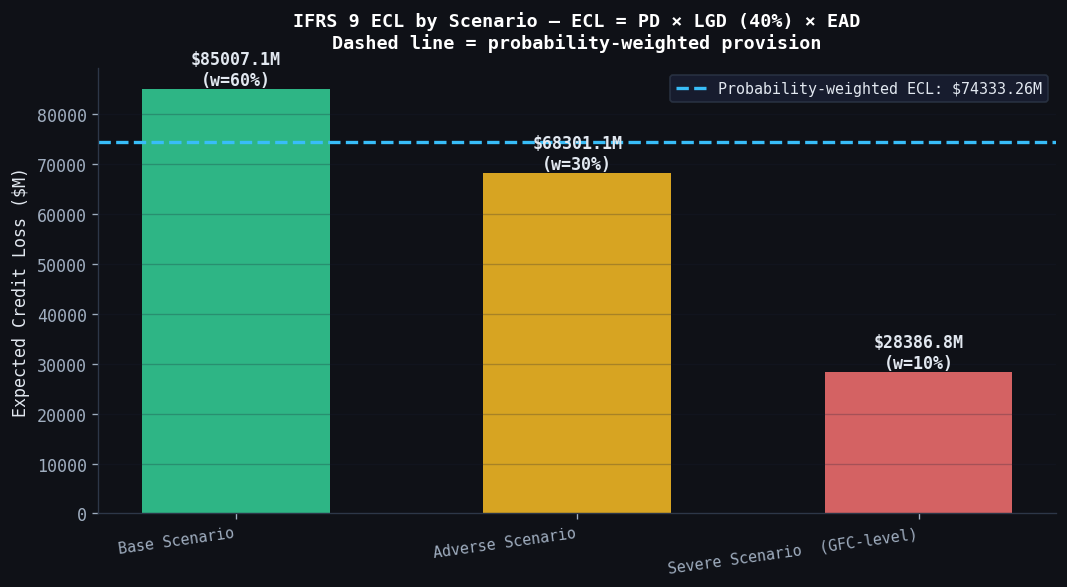

In [2]:
if (PROC/"scenario_ecl_summary.csv").exists():
    ecl = pd.read_csv(PROC/"scenario_ecl_summary.csv")
    print("IFRS 9 ECL Summary")
    print("=" * 60)
    print(ecl.to_string(index=False))
    print()

    # Bar chart
    plot_rows = ecl[~ecl["scenario"].str.contains("WEIGHTED", na=False)].copy()
    if not plot_rows.empty and "total_ecl_$M" in plot_rows.columns:
        weighted_val = ecl[ecl["scenario"].str.contains("WEIGHTED", na=False)
                          ]["weighted_ecl_$M"].values
        wv = float(weighted_val[0]) if len(weighted_val) else 0

        fig, ax = plt.subplots(figsize=(9, 5))
        colors_map = {"Base Scenario": C["green"], "Adverse Scenario": C["gold"],
                      "Severe Scenario  (GFC-level)": C["red"]}
        xs = range(len(plot_rows))
        for i, (_, row) in enumerate(plot_rows.iterrows()):
            col = colors_map.get(row["scenario"], C["sky"])
            bar = ax.bar(i, row["total_ecl_$M"], color=col, alpha=0.85,
                         edgecolor="none", width=0.55)
            ax.text(i, row["total_ecl_$M"] + 0.02,
                    f"${row['total_ecl_$M']:.1f}M\n(w={row['weight']:.0%})",
                    ha="center", va="bottom", fontsize=10, color="#E2E8F0",
                    fontweight="bold")

        ax.axhline(wv, color="#38BDF8", linewidth=2, linestyle="--",
                   label=f"Probability-weighted ECL: ${wv:.2f}M")
        ax.set_xticks(xs)
        ax.set_xticklabels([r["scenario"] for _, r in plot_rows.iterrows()],
                            fontsize=9, rotation=8, ha="right")
        ax.set_ylabel("Expected Credit Loss ($M)", fontsize=10)
        ax.set_title("IFRS 9 ECL by Scenario — ECL = PD × LGD (40%) × EAD\n"
                     "Dashed line = probability-weighted provision",
                     fontsize=11, fontweight="bold", color="white", pad=12)
        ax.legend(fontsize=9)
        ax.grid(True, axis="y", alpha=0.25)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        plt.tight_layout(); plt.show()


## 2. PD Distributions by Scenario

Under the severe scenario the entire PD distribution shifts rightward — many loans that were low-risk under base conditions become materially risky. The cumulative distribution (ECDF) shows how the 95th percentile tail responds to macro stress.


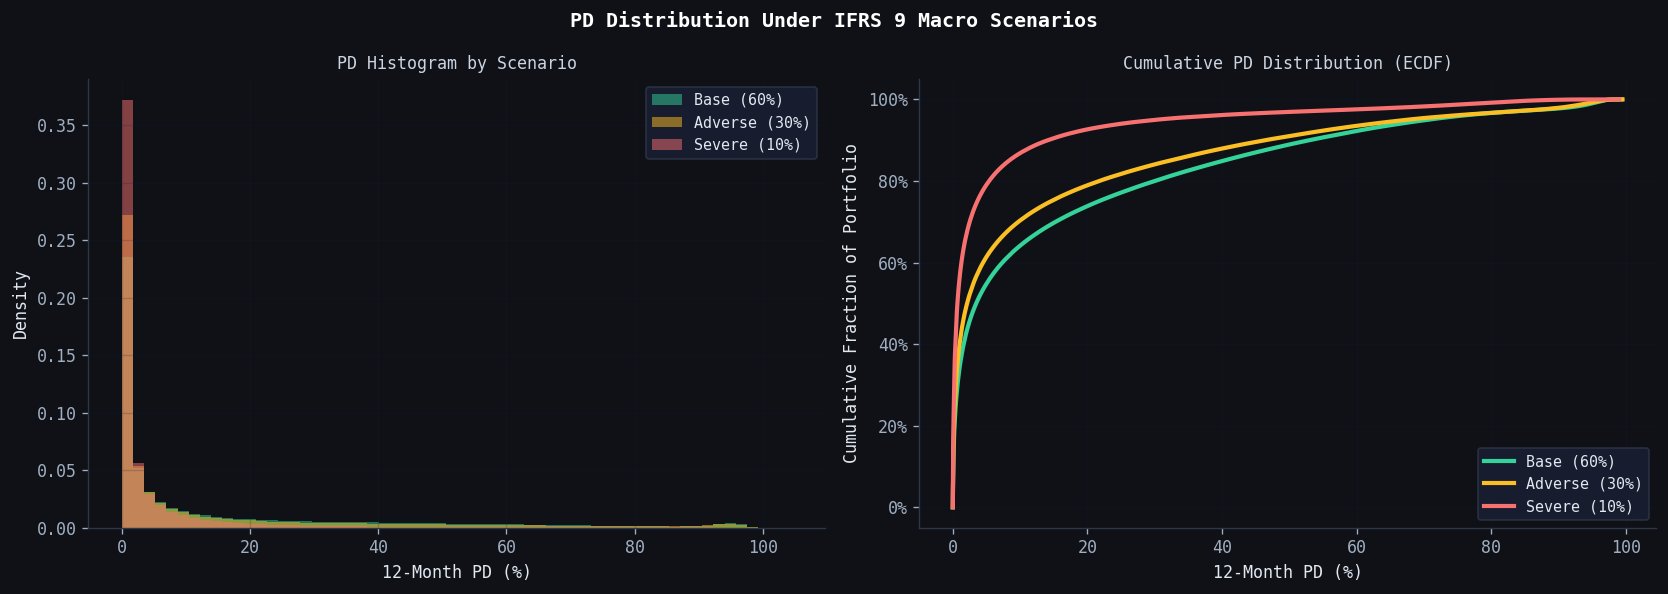


Scenario PD Statistics (%):
  Base (60%)          mean=15.6307  p50=3.4752  p95=70.5476  p99=94.9245
  Adverse (30%)       mean=13.0749  p50=2.1218  p95=67.4335  p99=94.1510
  Severe (10%)        mean=5.5809  p50=0.6823  p95=30.1298  p99=77.8661


In [3]:
if (PROC/"scenario_pd_by_loan.csv").exists():
    scen = pd.read_csv(PROC/"scenario_pd_by_loan.csv")
    pd_cols = [c for c in scen.columns if c.startswith("pd_")]
    scen_colors = {"pd_base": C["green"], "pd_adverse": C["gold"], "pd_severe": C["red"]}
    scen_labels = {"pd_base": "Base (60%)", "pd_adverse": "Adverse (30%)", "pd_severe": "Severe (10%)"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("PD Distribution Under IFRS 9 Macro Scenarios",
                 fontsize=12, fontweight="bold", color="white")

    # Histogram
    for col in pd_cols:
        if col in scen.columns:
            axes[0].hist(scen[col]*100, bins=60, alpha=0.5,
                         color=scen_colors.get(col,"#38BDF8"),
                         label=scen_labels.get(col, col), density=True,
                         range=(0, scen[pd_cols].max().max()*100*1.05))
    axes[0].set_xlabel("12-Month PD (%)", fontsize=10)
    axes[0].set_ylabel("Density", fontsize=10)
    axes[0].set_title("PD Histogram by Scenario", color="#CBD5E1", fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.2)
    axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

    # ECDF
    for col in pd_cols:
        if col in scen.columns:
            vals = np.sort(scen[col].dropna()*100)
            cdf  = np.linspace(0, 1, len(vals))
            axes[1].plot(vals, cdf, color=scen_colors.get(col,"#38BDF8"),
                         linewidth=2.5, label=scen_labels.get(col,col))
    axes[1].set_xlabel("12-Month PD (%)", fontsize=10)
    axes[1].set_ylabel("Cumulative Fraction of Portfolio", fontsize=10)
    axes[1].set_title("Cumulative PD Distribution (ECDF)", color="#CBD5E1", fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.2)
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()

    # Summary stats
    print("\nScenario PD Statistics (%):")
    for col in pd_cols:
        if col in scen.columns:
            v = scen[col].dropna() * 100
            print(f"  {scen_labels.get(col,col):18s}  "
                  f"mean={v.mean():.4f}  p50={v.quantile(.5):.4f}  "
                  f"p95={v.quantile(.95):.4f}  p99={v.quantile(.99):.4f}")


## 3. Macro Sensitivity — Tornado Chart

The sensitivity analysis answers: *by how many basis points does the portfolio PD increase for each unit shock to a macro variable?* This is the standard input to ALCO (Asset-Liability Committee) presentations.


Macro Sensitivity Analysis
   feature  shock  pd_base_pct  pd_shocked_pct  delta_pd_pp
 ur_3m_lag    1.0     15.91622        15.49505     -0.42118
hpi_change    0.1     15.91622        21.24346      5.32724



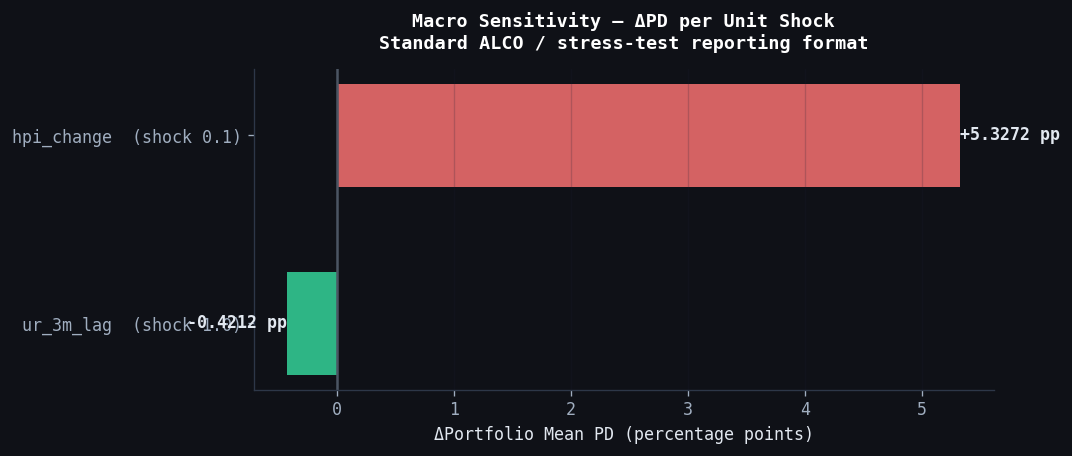

In [4]:
_SENS_COLS = ["feature", "shock", "pd_base_pct", "pd_shocked_pct", "delta_pd_pp"]

sens_path = PROC / "scenario_sensitivity.csv"
if sens_path.exists():
    try:
        sens = pd.read_csv(sens_path)
        if sens.empty:
            raise ValueError("empty")
    except Exception:
        sens = pd.DataFrame(columns=_SENS_COLS)
        print("\u26a0  scenario_sensitivity.csv is empty — macro features "
              "(hpi_change / ur_3m_lag) are all-NaN (macro files not supplied). "
              "Sensitivity chart skipped.")

    if not sens.empty:
        print("Macro Sensitivity Analysis")
        print("=" * 55)
        print(sens.to_string(index=False))
        print()

        if "delta_pd_pp" in sens.columns and len(sens) > 0:
            fig, ax = plt.subplots(figsize=(9, max(3.5, len(sens)*1.2 + 1.5)))
            y = np.arange(len(sens))
            deltas = sens["delta_pd_pp"].values
            labels = [f"{r['feature']}  (shock {r['shock']})"
                      for _, r in sens.iterrows()]
            colors = [C["red"] if d > 0 else C["green"] for d in deltas]
            ax.barh(y, deltas, color=colors, alpha=0.85, edgecolor="none", height=0.55)
            ax.axvline(0, color="#4B5563", linewidth=1.5)
            for yp, d in zip(y, deltas):
                ax.text(d + (0.0003 if d>=0 else -0.0003), yp,
                        f"{d:+.4f} pp", va="center",
                        ha="left" if d>=0 else "right",
                        fontsize=10, color="#E2E8F0", fontweight="bold")
            ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10)
            ax.set_xlabel("\u0394Portfolio Mean PD (percentage points)", fontsize=10)
            ax.set_title("Macro Sensitivity \u2014 \u0394PD per Unit Shock\n"
                         "Standard ALCO / stress-test reporting format",
                         fontsize=11, fontweight="bold", color="white", pad=12)
            ax.grid(True, axis="x", alpha=0.2)
            ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
            plt.tight_layout(); plt.show()


## Summary

| Output | Regulatory Purpose |
|---|---|
| Scenario PD by loan | IFRS 9 §5.5.17 — forward-looking MES inputs |
| Probability-weighted ECL | Balance sheet provision, Tier 1 capital impact |
| Sensitivity table | ICAAP stress testing, ALCO reporting |
| PD distribution shift | VaR / CVaR estimation under adverse conditions |

To customise scenarios for your institution: edit the `SCENARIOS` dict at the top of `07_macro_scenario_analysis.py` with your own ICAAP scenario parameters.
